# Gaussian Process Regression using Scikit-Learn for California Housing Price Prediction

This notebook presents an implementation of Gaussian Process Regression (GPR) using Scikit-Learn's built-in GaussianProcessRegressor. We predict the median house value in California census blocks using 8 building features from the California Housing dataset (20,640 samples).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel


## 2. Dataset Ingestion and Preprocessing

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().dropna()
print("Cleaned Shape:", df.shape)
df.describe()

Dataset Shape: (20640, 9)
Missing Values: 0
Duplicates: 0
Cleaned Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


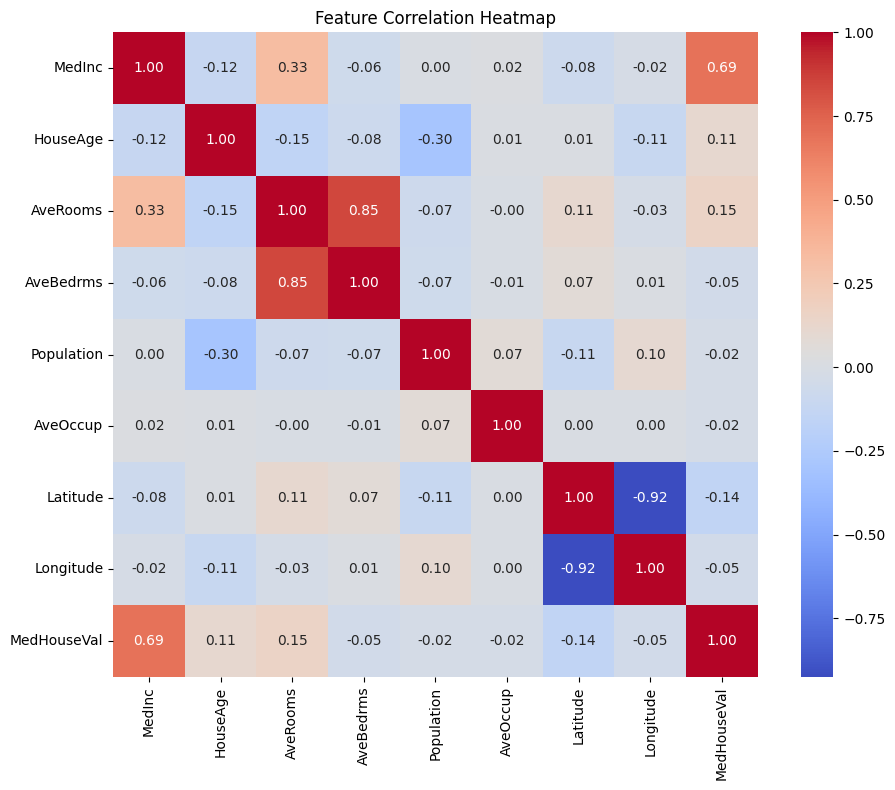

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [4]:
feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                "Population", "AveOccup", "Latitude", "Longitude"]
target_col = "MedHouseVal"

X = df[feature_cols].values
Y = df[target_col].values
print(f"Features shape: {X.shape}")
print(f"Target shape:   {Y.shape}")

Features shape: (20640, 8)
Target shape:   (20640,)


### 2.3 Train-Test Split & Feature Z-score Standardization

In [5]:
np.random.seed(42)
N = X.shape[0]
indices = np.random.permutation(N)
split = int(0.8 * N)

train_idx = indices[:split]
test_idx  = indices[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
Y_train_raw, Y_test_raw = Y[train_idx], Y[test_idx]

# Z-score standardisation (computed from training set only)
X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
Y_mean, Y_std = Y_train_raw.mean(), Y_train_raw.std()

X_train = (X_train_raw - X_mean) / X_std
X_test  = (X_test_raw  - X_mean) / X_std
Y_train = (Y_train_raw - Y_mean) / Y_std
Y_test  = (Y_test_raw  - Y_mean) / Y_std

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"X_train mean = {X_train.mean(axis=0).round(6)}")


Training samples: 16512
Test samples:     4128
X_train mean = [-0. -0. -0. -0. -0. -0. -0. -0.]


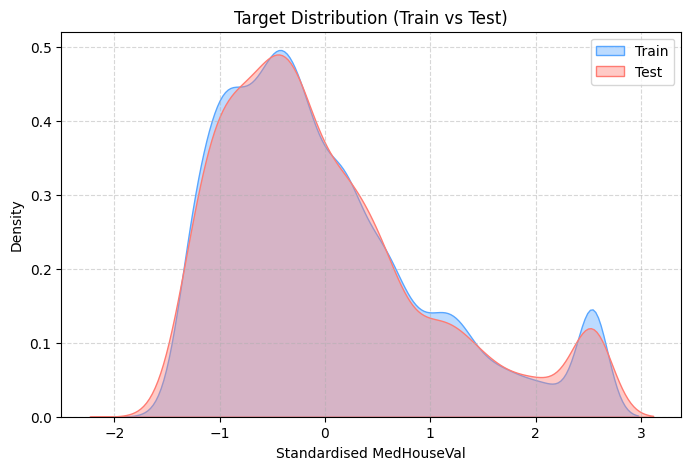

In [6]:
plt.figure(figsize=(8, 5))
sns.kdeplot(Y_train, label="Train", fill=True, alpha=0.4, color="#58a6ff")
sns.kdeplot(Y_test,  label="Test",  fill=True, alpha=0.4, color="#ff7b72")
plt.xlabel("Standardised MedHouseVal")
plt.ylabel("Density")
plt.title("Target Distribution (Train vs Test)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 2.4 Calculating Noise Variance dynamically from Dataset

In [7]:
# OLS: beta = (X^T X)^{-1} X^T y
X_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
beta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y_train
Y_pred_ols = X_bias @ beta
residuals = Y_train - Y_pred_ols
noise = np.var(residuals)


## 3. GPR Implementation with RBF Kernel

In [8]:
rbf_kernel = ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed")
print("Kernel:", rbf_kernel)

Kernel: 1**2 * RBF(length_scale=1)


In [9]:
gpr_rbf = GaussianProcessRegressor(
    kernel=rbf_kernel,
    alpha=noise,
    optimizer=None,
    normalize_y=True,
    random_state=42
)
gpr_rbf.fit(X_train, Y_train)
print("GPR fitted with RBF kernel.")
print("Kernel params:", gpr_rbf.kernel_)

GPR fitted with RBF kernel.
Kernel params: 1**2 * RBF(length_scale=1)


In [10]:
posterior_mean, posterior_std = gpr_rbf.predict(X_test, return_std=True)
posterior_mean_orig = posterior_mean * Y_std + Y_mean
posterior_std_orig = posterior_std * Y_std
print(f"Predictions shape: {posterior_mean.shape}")
print(f"Mean of posterior_mean (orig): {posterior_mean_orig.mean():.4f}")
print(f"Mean of posterior_std (orig):  {posterior_std_orig.mean():.4f}")


Predictions shape: (4128,)
Mean of posterior_mean (orig): 2.0680
Mean of posterior_std (orig):  0.1919


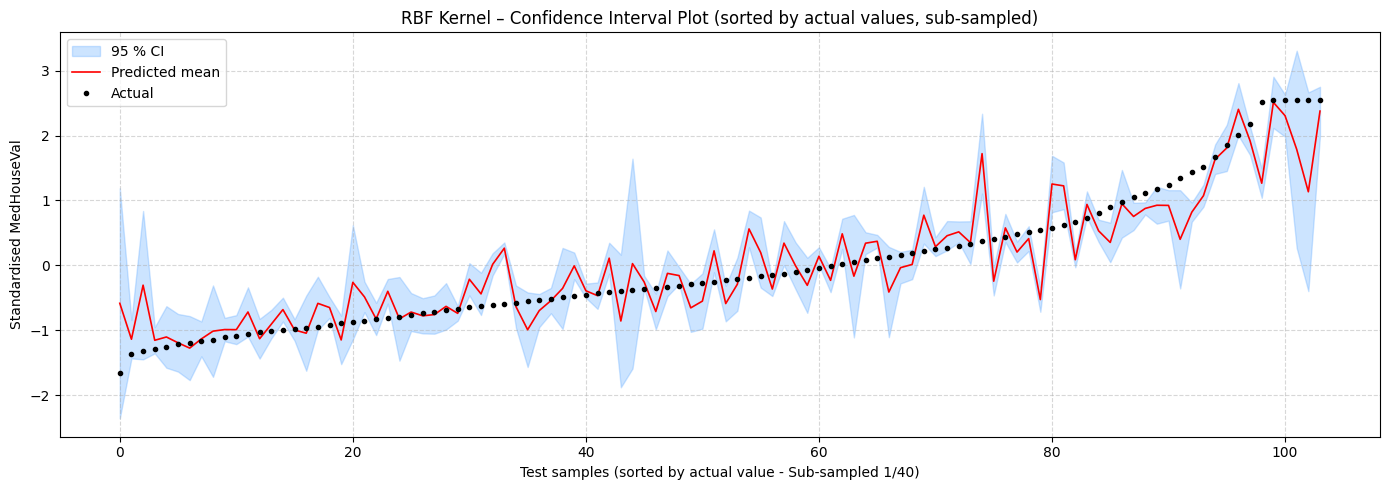

In [11]:
sort_idx = np.argsort(Y_test)
# Sub-sample every 40th instance to make the plot clean and readable
plot_idx = sort_idx[::40]
y_sorted = Y_test[plot_idx]
mu_sorted = posterior_mean[plot_idx]
std_sorted = posterior_std[plot_idx]

plt.figure(figsize=(14, 5))
x_axis = np.arange(len(y_sorted))
plt.fill_between(x_axis,
                 mu_sorted - 1.96 * std_sorted,
                 mu_sorted + 1.96 * std_sorted,
                 alpha=0.3, color="#58a6ff", label="95 % CI")
plt.plot(x_axis, mu_sorted, "r-", linewidth=1.2, label="Predicted mean")
plt.plot(x_axis, y_sorted, "k.", markersize=6, label="Actual")
plt.xlabel("Test samples (sorted by actual value - Sub-sampled 1/40)")
plt.ylabel("Standardised MedHouseVal")
plt.title("RBF Kernel – Confidence Interval Plot (sorted by actual values, sub-sampled)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 3.4 Quantifying Prediction Performance

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import norm

posterior_mean_orig = posterior_mean * Y_std + Y_mean
posterior_std_orig = posterior_std * Y_std

rmse = np.sqrt(mean_squared_error(Y_test_raw, posterior_mean_orig))
mae  = mean_absolute_error(Y_test_raw, posterior_mean_orig)
r2   = r2_score(Y_test_raw, posterior_mean_orig)

# NLL in original space
nll = -np.mean(norm.logpdf(Y_test_raw, loc=posterior_mean_orig, scale=posterior_std_orig))

print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R2   : {r2:.6f}")
print(f"NLL  : {nll:.6f}")


RMSE : 0.561079
MAE  : 0.386024
R2   : 0.766113
NLL  : 8.241371


## 5. Comparison of Covariance Functions (GPML Chapter 4)

In [13]:
ls_ard = np.array([3.19514982e+00, 4.83185779e+00, 3.84681630e+00, 2.36528444e+00,
                   1.73674472e+01, 8.38591952e-01, 9.34511052e-01, 1.11423844e+00])

kernels = {
    "RBF": ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed"),
    "Matern": ConstantKernel(1.0, "fixed") * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5),
    "RQ": ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.0, length_scale_bounds="fixed",
                                                            alpha=1.0, alpha_bounds="fixed"),
    "ARD": ConstantKernel(1.0, "fixed") * RBF(length_scale=ls_ard, length_scale_bounds="fixed"),
}

for name, k in kernels.items():
    print(f"{name:8s}: {k}")

RBF     : 1**2 * RBF(length_scale=1)
Matern  : 1**2 * Matern(length_scale=1, nu=1.5)
RQ      : 1**2 * RationalQuadratic(alpha=1, length_scale=1)
ARD     : 1**2 * RBF(length_scale=[3.2, 4.83, 3.85, 2.37, 17.4, 0.839, 0.935, 1.11])


In [14]:
results = {}
colors = ["#58a6ff", "#3fb950", "#ff7b72", "#ffa657"]

for i, (name, kernel) in enumerate(kernels.items()):
    print(f"Training {name} kernel...")
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=noise,
        optimizer=None,
        normalize_y=True,
        random_state=42
    )
    gpr.fit(X_train, Y_train)
    mu, std = gpr.predict(X_test, return_std=True)
    
    # Convert predictions to original scale
    mu_orig = mu * Y_std + Y_mean
    std_orig = std * Y_std
    
    # Optimize: Omit saving the whole model object to free gigabytes of memory!
    results[name] = {
        "mu": mu, 
        "std": std, 
        "mu_orig": mu_orig,
        "std_orig": std_orig,
        "color": colors[i]
    }
    print(f"   done ({name})")
    del gpr
    gc.collect()

print("\nAll kernels trained.")


Training RBF kernel...
   done (RBF)
Training Matern kernel...
   done (Matern)
Training RQ kernel...
   done (RQ)
Training ARD kernel...
   done (ARD)

All kernels trained.


In [15]:
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import norm

rows = []
for name, res in results.items():
    mu_o  = res["mu_orig"]
    std_o = res["std_orig"]
    _rmse = np.sqrt(mean_squared_error(Y_test_raw, mu_o))
    _mae  = mean_absolute_error(Y_test_raw, mu_o)
    _r2   = r2_score(Y_test_raw, mu_o)
    _mape = mean_absolute_percentage_error(Y_test_raw, mu_o) * 100
    _nll  = -np.mean(norm.logpdf(Y_test_raw, loc=mu_o, scale=std_o))
    rows.append({"Kernel": name, "RMSE": _rmse, "MAE": _mae,
                 "R2": _r2, "MAPE (%)": _mape, "NLL": _nll}) # R2 character

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))


Kernel     RMSE      MAE       R2  MAPE (%)       NLL
   RBF 0.561079 0.386024 0.766113 21.666649  8.241371
Matern 0.554475 0.379147 0.771586 21.083770  1.191968
    RQ 0.552962 0.378867 0.772831 21.092703  3.550156
   ARD 0.562854 0.383742 0.764630 21.020270 79.983023


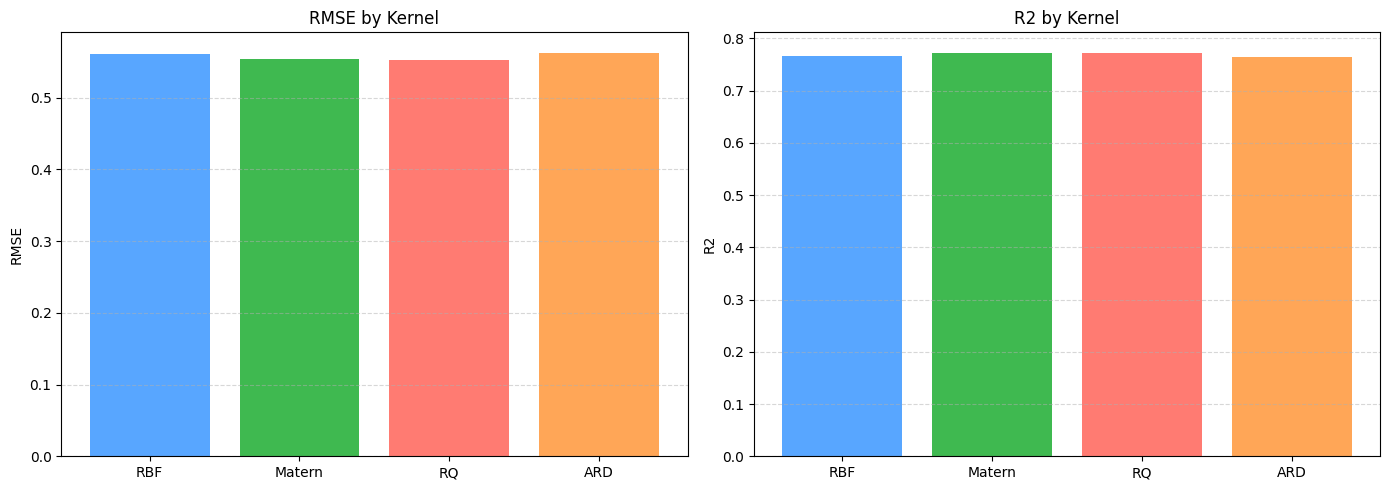

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].bar(comparison_df["Kernel"], comparison_df["RMSE"], color=colors)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE by Kernel")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

# R2
axes[1].bar(comparison_df["Kernel"], comparison_df["R2"], color=colors)
axes[1].set_ylabel("R2")
axes[1].set_title("R2 by Kernel")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()


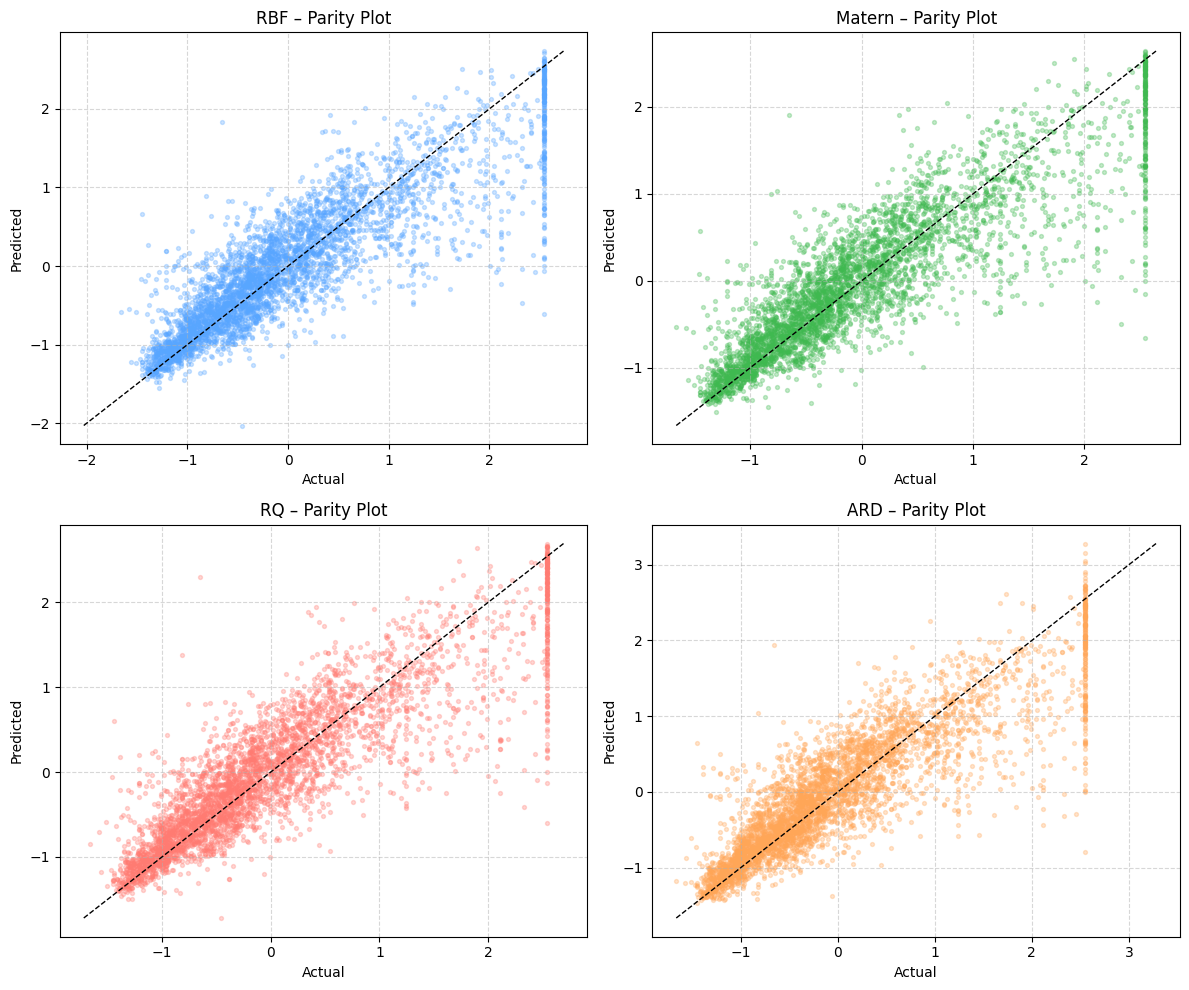

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    ax.scatter(Y_test, res["mu"], alpha=0.3, s=8, color=res["color"])
    lims = [min(Y_test.min(), res["mu"].min()), max(Y_test.max(), res["mu"].max())]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} – Parity Plot")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

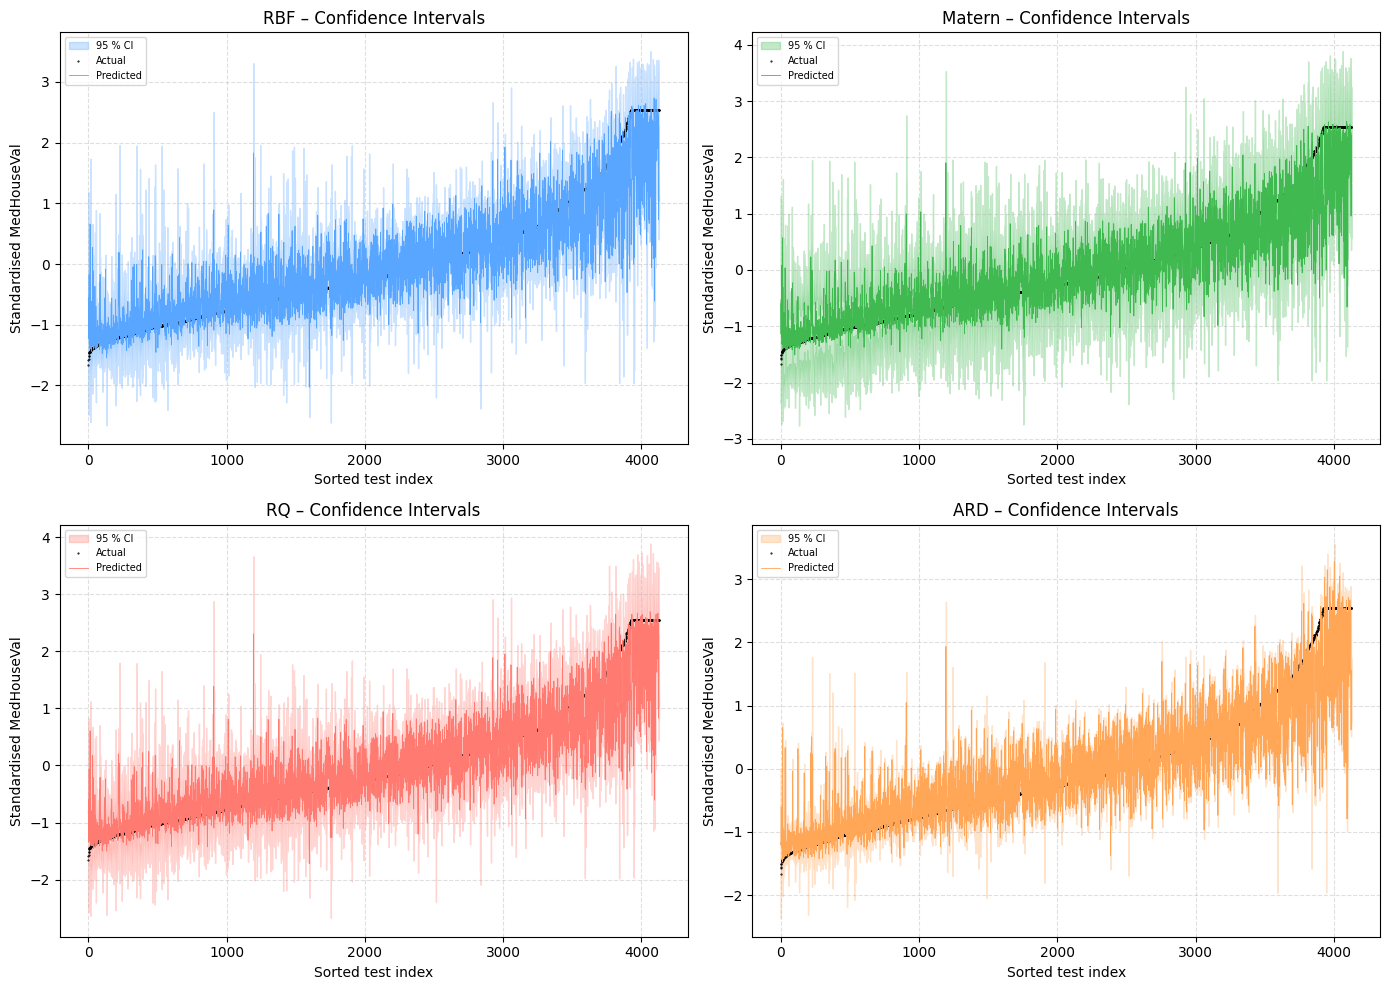

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    si = np.argsort(Y_test)
    x_ax = np.arange(len(Y_test))
    ax.fill_between(x_ax,
                    res["mu"][si] - 1.96 * res["std"][si],
                    res["mu"][si] + 1.96 * res["std"][si],
                    alpha=0.3, color=res["color"], label="95 % CI")
    ax.plot(x_ax, Y_test[si], "k.", markersize=1, label="Actual")
    ax.plot(x_ax, res["mu"][si], color=res["color"], linewidth=0.6, label="Predicted")
    ax.set_title(f"{name} – Confidence Intervals")
    ax.set_xlabel("Sorted test index")
    ax.set_ylabel("Standardised MedHouseVal")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

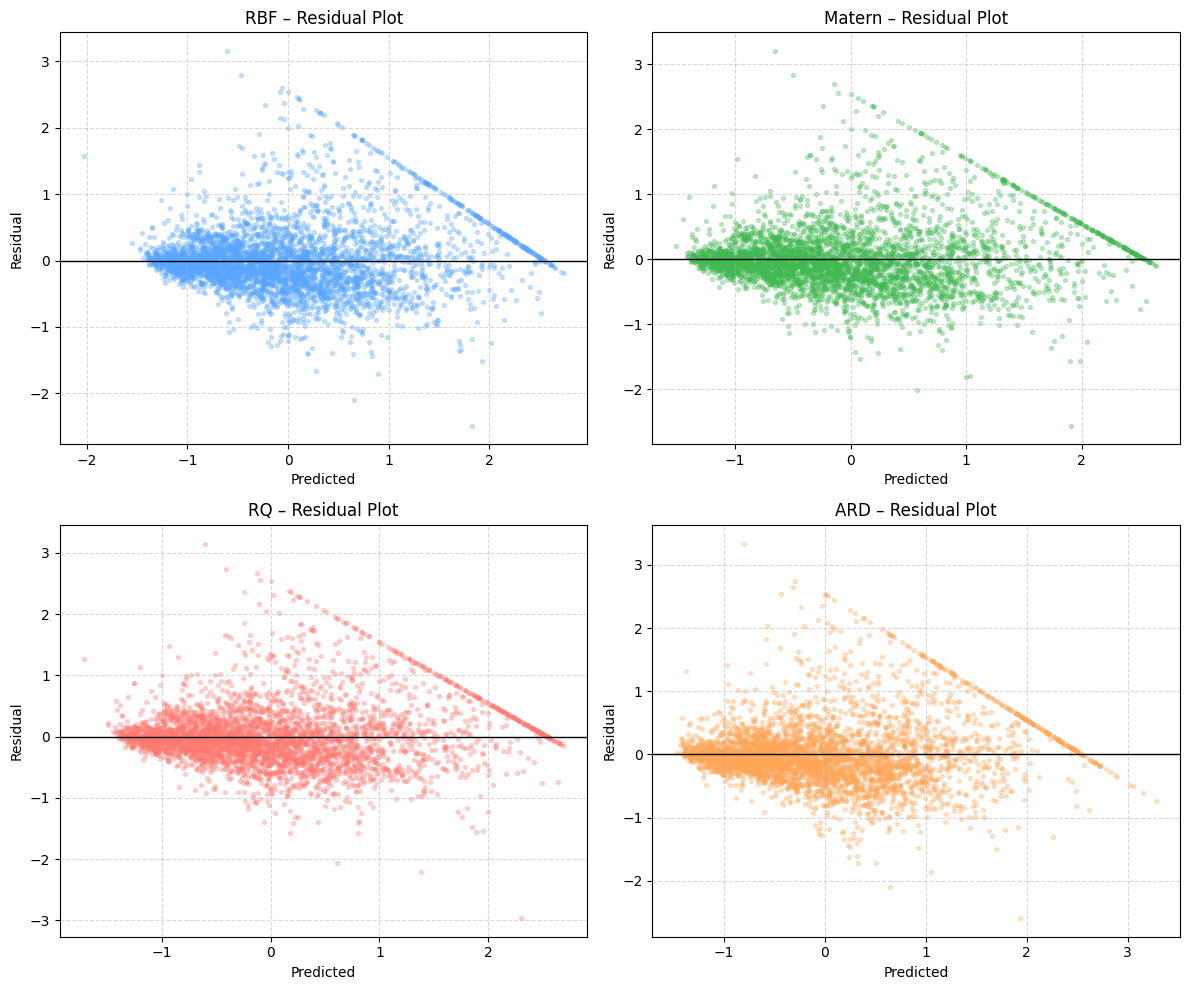

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    residual = Y_test - res["mu"]
    ax.scatter(res["mu"], residual, alpha=0.3, s=8, color=res["color"])
    ax.axhline(0, color="k", linewidth=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(f"{name} – Residual Plot")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

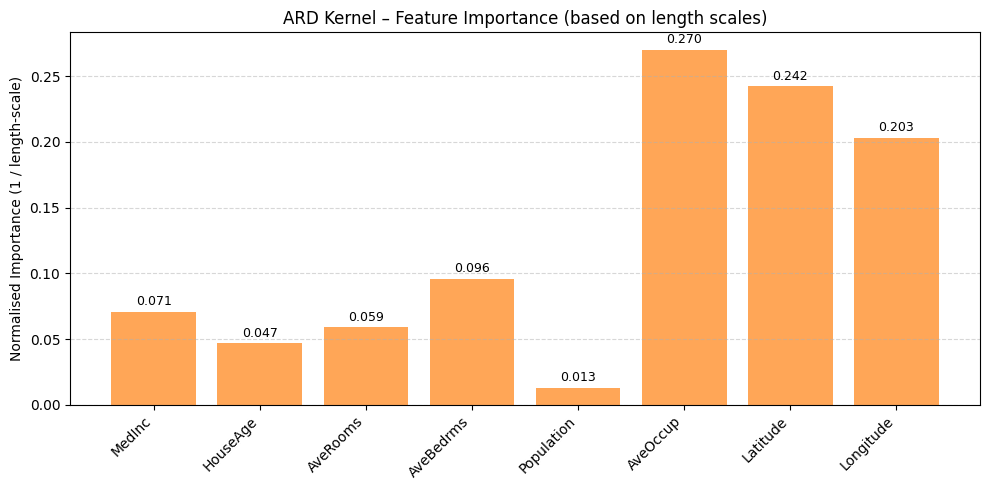

In [20]:
# ARD length-scale based feature importance
# Shorter length scale → feature changes the function more rapidly → more important
importance = 1.0 / ls_ard
importance_norm = importance / importance.sum()

plt.figure(figsize=(10, 5))
bars = plt.bar(feature_cols, importance_norm, color="#ffa657")
plt.ylabel("Normalised Importance (1 / length-scale)")
plt.title("ARD Kernel – Feature Importance (based on length scales)")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, importance_norm):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=9)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
# Show first 20 test predictions for the best kernel (ARD) on original scale
sample_df = pd.DataFrame({
    "Actual":    Y_test_raw[:20],
    "Predicted": results["ARD"]["mu_orig"][:20],
    "Std":       results["ARD"]["std_orig"][:20],
    "Error":     np.abs(Y_test_raw[:20] - results["ARD"]["mu_orig"][:20])
})
print(sample_df.to_string(index=False))


 Actual  Predicted      Std    Error
  0.588   0.845246 0.048107 0.257246
  1.658   1.767219 0.022368 0.109219
  1.394   2.119782 0.033573 0.725782
  1.075   1.314912 0.048567 0.239912
  1.072   1.149468 0.152183 0.077468
  3.533   3.451837 0.064250 0.081163
  1.294   1.216218 0.048803 0.077782
  1.131   0.906881 0.076136 0.224119
  3.453   3.563217 0.038139 0.110217
  2.346   2.541826 0.056248 0.195826
  1.122   1.381213 0.035679 0.259213
  1.358   1.166956 0.045902 0.191044
  3.250   2.844939 0.060753 0.405061
  0.777   0.874486 0.035498 0.097486
  1.118   1.288292 0.027771 0.170292
  1.350   1.893675 0.075611 0.543675
  2.351   3.101605 0.025686 0.750605
  1.486   1.985785 0.051624 0.499785
  2.625   1.486338 0.234501 1.138662
  1.482   2.630135 0.062997 1.148135


In [22]:
# Pick the first test point and show full detail
idx_point = 0
print("=== Single Point Prediction Detail ===")
print(f"Test index            : {idx_point}")
print(f"Actual  (standardised): {Y_test[idx_point]:.6f}")
for name, res in results.items():
    mu_i  = res["mu"][idx_point]
    std_i = res["std"][idx_point]
    lo = mu_i - 1.96 * std_i
    hi = mu_i + 1.96 * std_i
    print(f"  {name:8s}  predicted={mu_i:.6f}  std={std_i:.6f}  95%CI=[{lo:.4f}, {hi:.4f}]")


=== Single Point Prediction Detail ===
Test index            : 0
Actual  (standardised): -1.284088
  RBF       predicted=-1.027926  std=0.099929  95%CI=[-1.2238, -0.8321]
  Matern    predicted=-1.110625  std=0.279945  95%CI=[-1.6593, -0.5619]
  RQ        predicted=-1.076267  std=0.156015  95%CI=[-1.3821, -0.7705]
  ARD       predicted=-1.060854  std=0.041746  95%CI=[-1.1427, -0.9790]


### 5.6 1-D GP Visualizations

In [23]:
corr_with_target = df[feature_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
print("Correlation with MedHouseVal (|r|):")
print(corr_with_target.to_string())

Correlation with MedHouseVal (|r|):
MedInc        0.688075
AveRooms      0.151948
Latitude      0.144160
HouseAge      0.105623
AveBedrms     0.046701
Longitude     0.045967
Population    0.024650
AveOccup      0.023737


In [24]:
def gp_plot_1d(X_1d, Y_1d, kernel, title, xlabel, ylabel="MedHouseVal",
               n_grid=200, alpha_noise=0.1, color="#58a6ff"):
    """Fit a 1-D sklearn GP and plot mean ± 2sigma."""
    X_1d = X_1d.reshape(-1, 1)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_noise,
                                  optimizer=None, normalize_y=True,
                                  random_state=42)
    gp.fit(X_1d, Y_1d)
    X_grid = np.linspace(X_1d.min(), X_1d.max(), n_grid).reshape(-1, 1)
    mu, std = gp.predict(X_grid, return_std=True)

    plt.figure(figsize=(10, 5))
    plt.scatter(X_1d, Y_1d, s=4, alpha=0.15, color="grey", label="Data")
    plt.plot(X_grid, mu, color=color, linewidth=2, label="GP mean")
    plt.fill_between(X_grid.ravel(), mu - 2*std, mu + 2*std,
                     alpha=0.25, color=color, label="±2sigma")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Subsample 2000 points for 1-D visualisation
np.random.seed(42)
idx_sub = np.random.choice(len(df), size=2000, replace=False)
df_sub = df.iloc[idx_sub]
medinc_1d = df_sub["MedInc"].values
target_1d = df_sub["MedHouseVal"].values


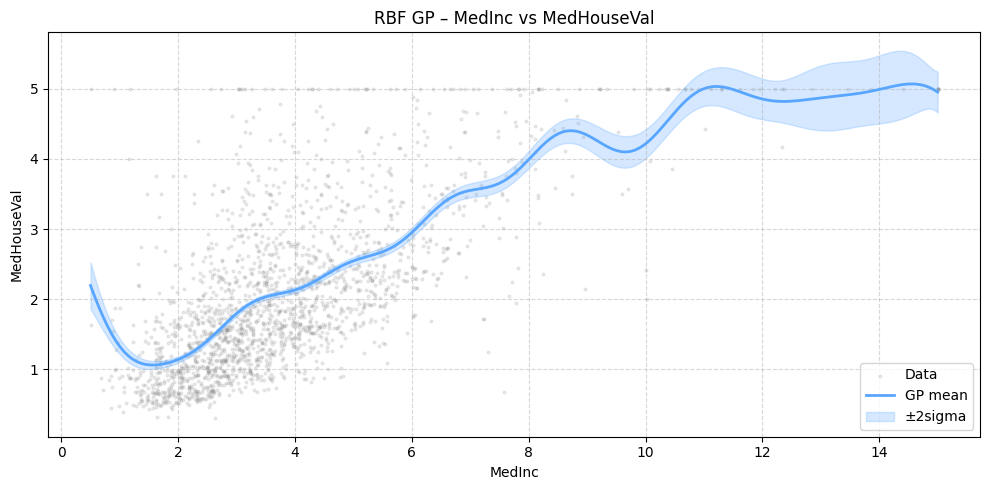

In [25]:
k_rbf_1d = ConstantKernel(1.0, "fixed") * RBF(length_scale=1.0, length_scale_bounds="fixed")
gp_plot_1d(medinc_1d, target_1d, k_rbf_1d,
           title="RBF GP – MedInc vs MedHouseVal",
           xlabel="MedInc", color="#58a6ff")

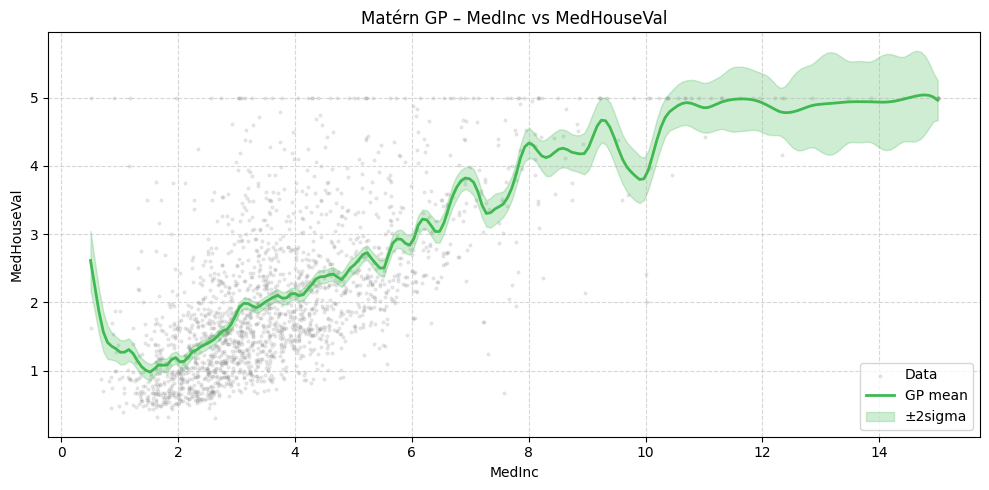

In [26]:
k_mat_1d = ConstantKernel(1.0, "fixed") * Matern(length_scale=1.0, length_scale_bounds="fixed", nu=1.5)
gp_plot_1d(medinc_1d, target_1d, k_mat_1d,
           title="Matérn GP – MedInc vs MedHouseVal",
           xlabel="MedInc", color="#3fb950")

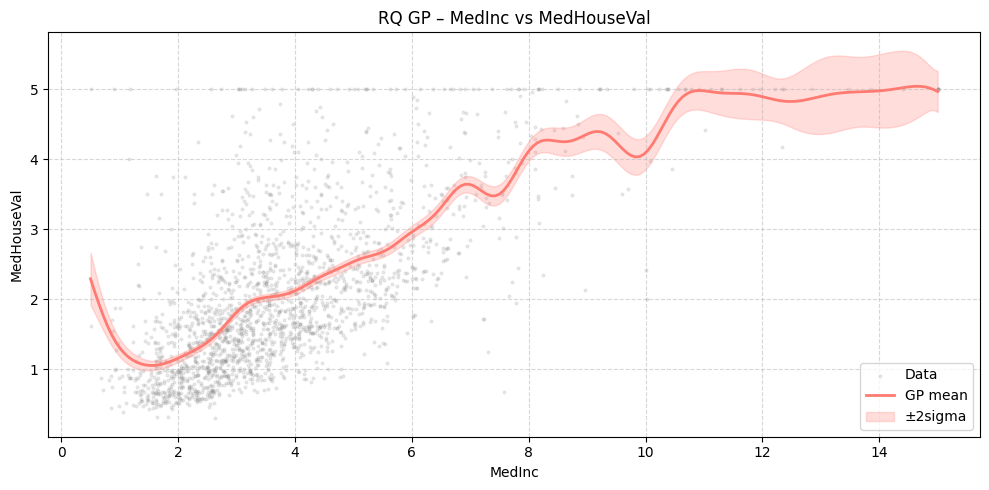

In [27]:
k_rq_1d = ConstantKernel(1.0, "fixed") * RationalQuadratic(length_scale=1.0, length_scale_bounds="fixed",
                                                             alpha=1.0, alpha_bounds="fixed")
gp_plot_1d(medinc_1d, target_1d, k_rq_1d,
           title="RQ GP – MedInc vs MedHouseVal",
           xlabel="MedInc", color="#ff7b72")

In [28]:
lat_1d = df_sub["Latitude"].values
print(f"Latitude 1-D data prepared, n={len(lat_1d)}")

Latitude 1-D data prepared, n=2000


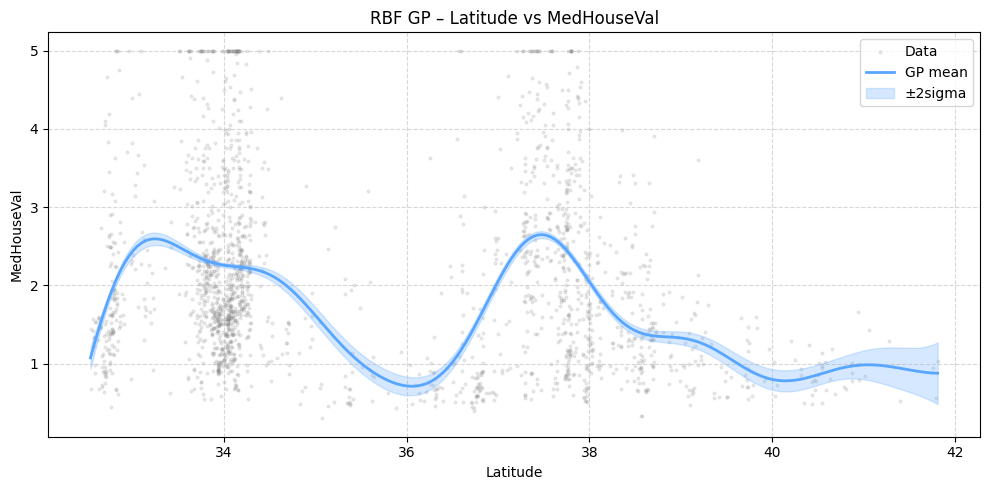

In [29]:
gp_plot_1d(lat_1d, target_1d, k_rbf_1d,
           title="RBF GP – Latitude vs MedHouseVal",
           xlabel="Latitude", color="#58a6ff")

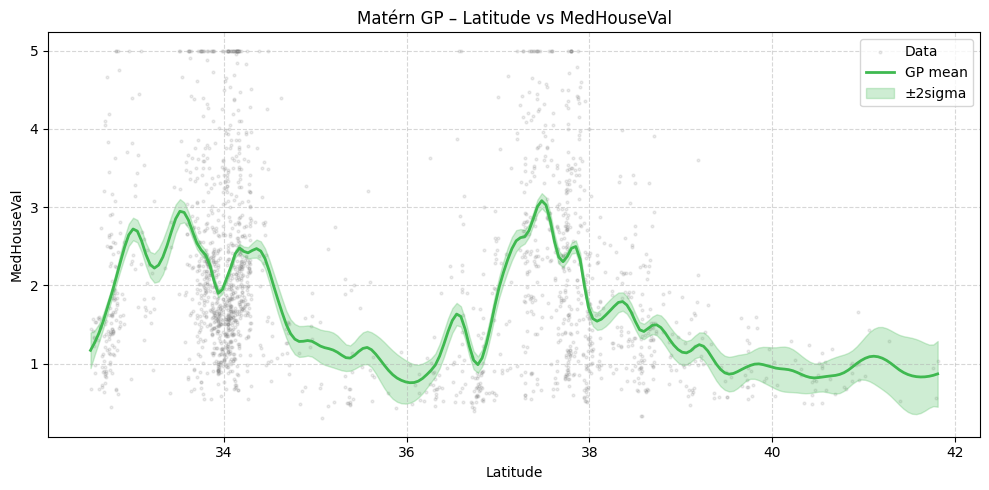

In [30]:
gp_plot_1d(lat_1d, target_1d, k_mat_1d,
           title="Matérn GP – Latitude vs MedHouseVal",
           xlabel="Latitude", color="#3fb950")

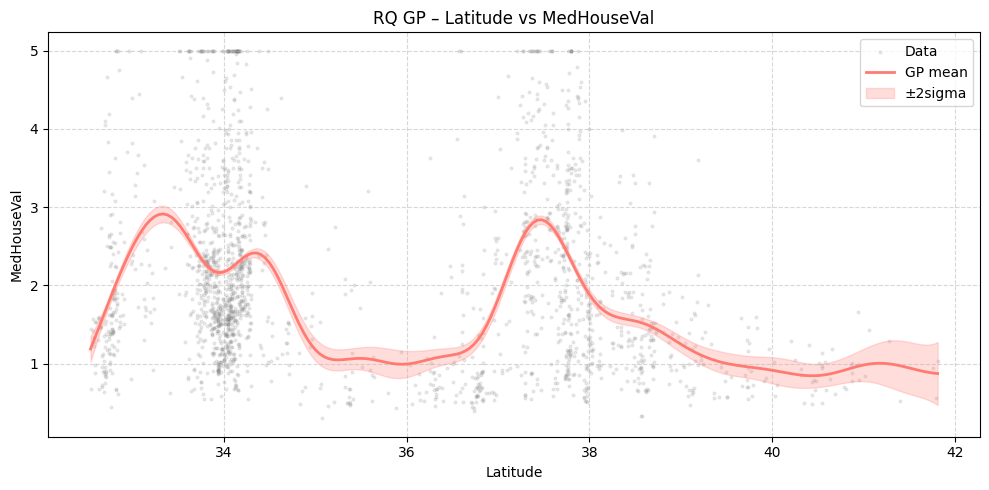

In [31]:
gp_plot_1d(lat_1d, target_1d, k_rq_1d,
           title="RQ GP – Latitude vs MedHouseVal",
           xlabel="Latitude", color="#ff7b72")

## 6. Comparison with Baseline Machine Learning Models

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

class PolynomialRegressionSklearn:
    """Wrapper: fits LinearRegression on [X, X^2]."""
    def __init__(self):
        self.model = LinearRegression()
    def fit(self, X, y):
        self.model.fit(np.hstack([X, X**2]), y)
        return self
    def predict(self, X):
        return self.model.predict(np.hstack([X, X**2]))

baselines = {
    "Linear":      LinearRegression(),
    "Poly-2":      PolynomialRegressionSklearn(),
    "KNN (k=5)":   KNeighborsRegressor(n_neighbors=5),
    "DecTree (d5)": DecisionTreeRegressor(max_depth=5, random_state=42),
}

baseline_results = {}
for name, model in baselines.items():
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    pred_orig = pred * Y_std + Y_mean
    baseline_results[name] = {"pred": pred, "pred_orig": pred_orig}
    print(f"{name:16s} trained  RMSE = {np.sqrt(mean_squared_error(Y_test_raw, pred_orig)):.6f}")


Linear           trained  RMSE = 0.745104
Poly-2           trained  RMSE = 0.754783
KNN (k=5)        trained  RMSE = 0.652351
DecTree (d5)     trained  RMSE = 0.734604


In [33]:
bl_rows = []
for name, res in baseline_results.items():
    pred_o = res["pred_orig"]
    _rmse = np.sqrt(mean_squared_error(Y_test_raw, pred_o))
    _mae  = mean_absolute_error(Y_test_raw, pred_o)
    _r2   = r2_score(Y_test_raw, pred_o)
    _mape = mean_absolute_percentage_error(Y_test_raw, pred_o) * 100
    bl_rows.append({"Model": name, "RMSE": _rmse, "MAE": _mae,
                    "R2": _r2, "MAPE (%)": _mape})

baseline_df = pd.DataFrame(bl_rows)
print(baseline_df.to_string(index=False))


       Model     RMSE      MAE       R2  MAPE (%)
      Linear 0.745104 0.542190 0.587529 31.960043
      Poly-2 0.754783 0.532936 0.576744 31.165014
   KNN (k=5) 0.652351 0.443630 0.683830 23.737608
DecTree (d5) 0.734604 0.534429 0.599073 32.681689


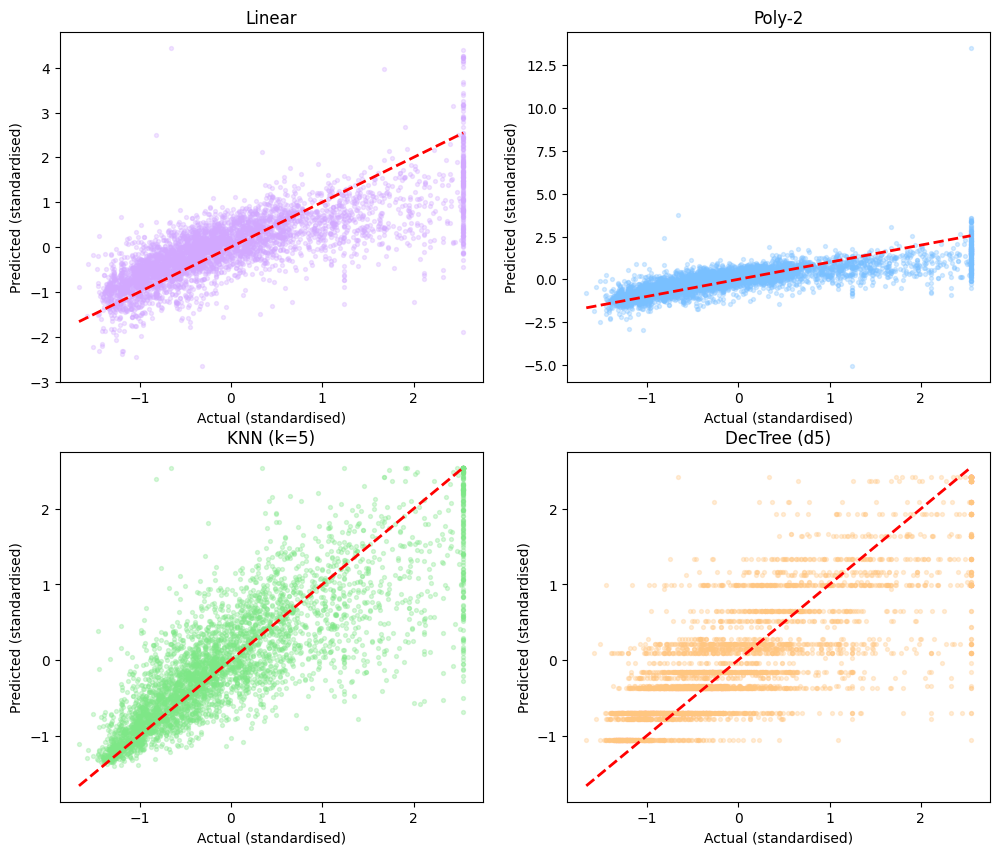

In [34]:
bl_colors = ["#d2a8ff", "#79c0ff", "#7ee787", "#ffc680"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx_bl, (name, res) in enumerate(baseline_results.items()):
    ax = axes[idx_bl]
    pred_std = res["pred"]
    ax.scatter(Y_test, pred_std, alpha=0.3, s=8, color=bl_colors[idx_bl])
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--", lw=2)
    ax.set_title(name)
    ax.set_xlabel("Actual (standardised)")
    ax.set_ylabel("Predicted (standardised)")


## 7. Summary and Model Ranking

In [35]:
# Combine GPR and baseline results into one ranking table
from sklearn.metrics import mean_absolute_percentage_error
all_rows = []

# GPR kernels
for name, res in results.items():
    mu_o = res["mu_orig"]
    _rmse = np.sqrt(mean_squared_error(Y_test_raw, mu_o))
    _r2   = r2_score(Y_test_raw, mu_o)
    _mae  = mean_absolute_error(Y_test_raw, mu_o)
    _mape = mean_absolute_percentage_error(Y_test_raw, mu_o)
    all_rows.append({"Model": f"GPR ({name})", "RMSE": _rmse, "R2": _r2,
                     "MAE": _mae, "Accuracy (%)": (1 - _mape) * 100})

# Baselines
for name, res in baseline_results.items():
    pred_o = res["pred_orig"]
    _rmse = np.sqrt(mean_squared_error(Y_test_raw, pred_o))
    _r2   = r2_score(Y_test_raw, pred_o)
    _mae  = mean_absolute_error(Y_test_raw, pred_o)
    _mape = mean_absolute_percentage_error(Y_test_raw, pred_o)
    all_rows.append({"Model": name, "RMSE": _rmse, "R2": _r2,
                     "MAE": _mae, "Accuracy (%)": (1 - _mape) * 100})

ranking_df = pd.DataFrame(all_rows).sort_values("RMSE")
ranking_df.index = range(1, len(ranking_df) + 1)
ranking_df.index.name = "Rank"
print(ranking_df.to_string())


             Model      RMSE        R2       MAE  Accuracy (%)
Rank                                                          
1         GPR (RQ)  0.552962  0.772831  0.378867     78.907297
2     GPR (Matern)  0.554475  0.771586  0.379147     78.916230
3        GPR (RBF)  0.561079  0.766113  0.386024     78.333351
4        GPR (ARD)  0.562854  0.764630  0.383742     78.979730
5        KNN (k=5)  0.652351  0.683830  0.443630     76.262392
6     DecTree (d5)  0.734604  0.599073  0.534429     67.318311
7           Linear  0.745104  0.587529  0.542190     68.039957
8           Poly-2  0.754783  0.576744  0.532936     68.834986


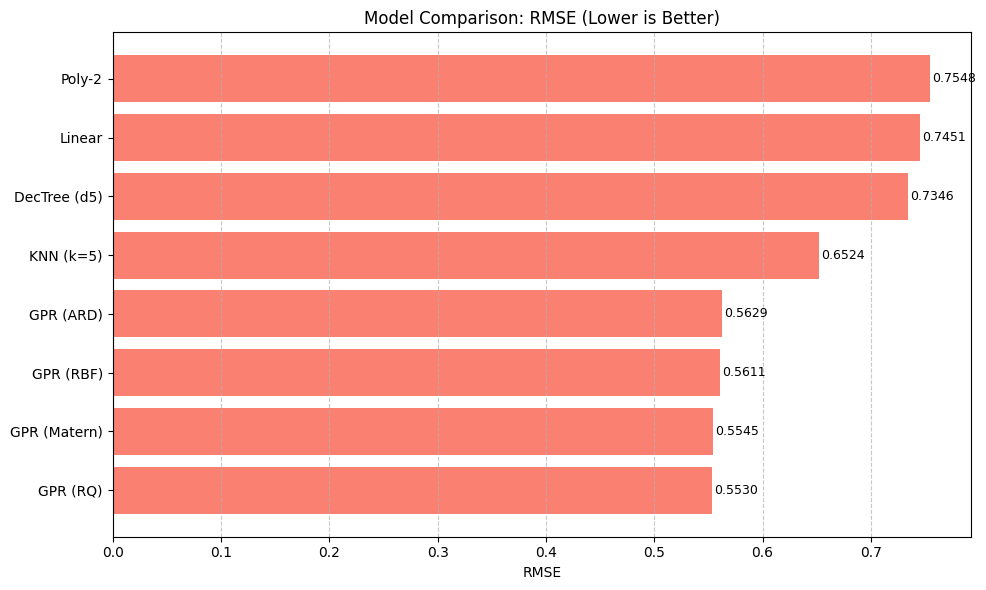

In [36]:
ranking_df_sorted = ranking_df.sort_values("RMSE")
plt.figure(figsize=(10, 6))
bars = plt.barh(ranking_df_sorted["Model"], ranking_df_sorted["RMSE"], color="salmon")
plt.xlabel("RMSE")
plt.title("Model Comparison: RMSE (Lower is Better)")
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f"{width:.4f}",
             va="center", ha="left", fontsize=9)
plt.grid(True, axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

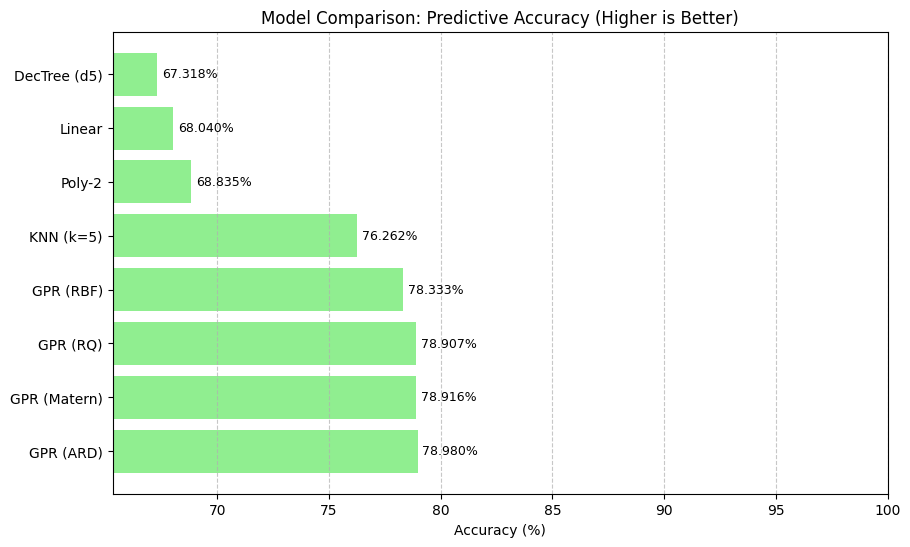

In [37]:
ranking_df_sorted_acc = ranking_df.sort_values("Accuracy (%)", ascending=False)
plt.figure(figsize=(10, 6))
bars = plt.barh(ranking_df_sorted_acc["Model"], ranking_df_sorted_acc["Accuracy (%)"], color="lightgreen")
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison: Predictive Accuracy (Higher is Better)")
plt.xlim(ranking_df["Accuracy (%)"].min() - 2, 100)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.3f}%",
             va="center", ha="left", fontsize=9)
plt.grid(True, axis="x", linestyle="--", alpha=0.7)
plt.show()